In [1]:
#Cell 1
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback, ReduceLROnPlateau
from tensorflow.keras.layers import (Input, Conv3D, MaxPooling3D, UpSampling3D,
                                      BatchNormalization, Activation, Multiply,
                                      Add, Concatenate, SpatialDropout3D, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("Memory growth enabled")
else:
    print("WARNING: No GPU found. Training will be very slow.")

# Paths
BASE  = '/content/drive/MyDrive/LungTumour/'
LOCAL = '/content/lung_data/'
os.makedirs(LOCAL, exist_ok=True)

print("BASE path:", BASE)
print("LOCAL path:", LOCAL)
print("Setup complete.")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled
BASE path: /content/drive/MyDrive/LungTumour/
LOCAL path: /content/lung_data/
Setup complete.


In [3]:
# Step 1 — Force unmount and remount Drive
from google.colab import drive
drive.flush_and_unmount()
print("Unmounted.")

drive.mount('/content/drive', force_remount=True)
print("Remounted.")

Unmounted.
Mounted at /content/drive
Remounted.


In [5]:
import os
import subprocess

# Delete corrupted y_train
corrupted = LOCAL + 'y_train.npy'
os.remove(corrupted)
print("Deleted corrupted y_train.npy")

# Recopy from Drive
result = subprocess.run(['cp', BASE + 'y_train.npy', LOCAL + 'y_train.npy'], capture_output=True)
if result.returncode == 0:
    print("y_train.npy recopied successfully")
else:
    print("FAILED:", result.stderr.decode())

# Verify size
size = os.path.getsize(LOCAL + 'y_train.npy')
print(f"File size: {size / 1024 / 1024:.1f} MB")

Deleted corrupted y_train.npy
y_train.npy recopied successfully
File size: 920.5 MB


In [6]:
#Cell 2
from google.colab import drive
drive.mount('/content/drive')

# Copy data from Drive to local for faster I/O during training
import shutil

files = ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']

print("Copying data to local storage...")
for f in files:
    src = BASE + f
    dst = LOCAL + f
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"  Copied: {f}")
    else:
        print(f"  Already exists: {f}")

# Load arrays
print("\nLoading arrays...")
X_train = np.load(LOCAL + 'X_train.npy')
y_train = np.load(LOCAL + 'y_train.npy')
X_val   = np.load(LOCAL + 'X_val.npy')
y_val   = np.load(LOCAL + 'y_val.npy')
X_test  = np.load(LOCAL + 'X_test.npy')
y_test  = np.load(LOCAL + 'y_test.npy')

# Verify shapes
print("\nShapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

print("\nData types:", X_train.dtype, y_train.dtype)
print("X range: [{:.3f}, {:.3f}]".format(X_train.min(), X_train.max()))
print("y unique values:", np.unique(y_train))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying data to local storage...
  Already exists: X_train.npy
  Already exists: y_train.npy
  Already exists: X_val.npy
  Already exists: y_val.npy
  Already exists: X_test.npy
  Already exists: y_test.npy

Loading arrays...

Shapes:
  X_train: (1841, 8, 128, 128, 1), y_train: (1841, 8, 128, 128, 1)
  X_val:   (394, 8, 128, 128, 1),   y_val:   (394, 8, 128, 128, 1)
  X_test:  (395, 8, 128, 128, 1),  y_test:  (395, 8, 128, 128, 1)

Data types: float32 float32
X range: [0.000, 1.000]
y unique values: [0. 1.]


In [7]:
#Cell 3

def attention_gate(x, g, filters):
    theta_x = Conv3D(filters, kernel_size=1, strides=1, padding='same',
                     kernel_regularizer=l2(1e-4))(x)
    phi_g   = Conv3D(filters, kernel_size=1, strides=1, padding='same',
                     kernel_regularizer=l2(1e-4))(g)
    add     = Add()([theta_x, phi_g])
    act     = Activation('relu')(add)
    psi     = Conv3D(1, kernel_size=1, strides=1, padding='same',
                     kernel_regularizer=l2(1e-4))(act)
    sig     = Activation('sigmoid')(psi)
    return Multiply()([x, sig])

def conv_block(x, filters, dropout_rate=0.1):
    x = Conv3D(filters, kernel_size=3, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout3D(dropout_rate)(x)
    x = Conv3D(filters, kernel_size=3, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_attention_unet(input_shape=(8, 128, 128, 1), filters=[16, 32, 64, 128]):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, filters[0])
    p1 = MaxPooling3D(pool_size=(1, 2, 2))(c1)

    c2 = conv_block(p1, filters[1])
    p2 = MaxPooling3D(pool_size=(1, 2, 2))(c2)

    c3 = conv_block(p2, filters[2])
    p3 = MaxPooling3D(pool_size=(1, 2, 2))(c3)

    # Bottleneck
    c4 = conv_block(p3, filters[3])

    # Decoder
    u5 = UpSampling3D(size=(1, 2, 2))(c4)
    a5 = attention_gate(c3, u5, filters[2])
    u5 = Concatenate()([u5, a5])
    c5 = conv_block(u5, filters[2])

    u6 = UpSampling3D(size=(1, 2, 2))(c5)
    a6 = attention_gate(c2, u6, filters[1])
    u6 = Concatenate()([u6, a6])
    c6 = conv_block(u6, filters[1])

    u7 = UpSampling3D(size=(1, 2, 2))(c6)
    a7 = attention_gate(c1, u7, filters[0])
    u7 = Concatenate()([u7, a7])
    c7 = conv_block(u7, filters[0])

    outputs = Conv3D(1, kernel_size=1, activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    return model

# Build model
model = build_attention_unet(input_shape=(8, 128, 128, 1), filters=[16, 32, 64, 128])
model.summary()
print("\nTotal params:", model.count_params())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 8, 128,    │        448 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 128,    │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d   │ (None, 8, 128,    │          0 │ activation[0][0]  │
│ (SpatialDropout3D)  │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 8, 128,    │      6,928 │ spatial_dropout3… │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │         64 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 8, 64, 64, │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 64, 64, │     13,856 │ max_pooling3d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d_1 │ (None, 8, 64, 64, │          0 │ activation_2[0][… │
│ (SpatialDropout3D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 8, 64, 64, │     27,680 │ spatial_dropout3… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 8, 32, 32, │          0 │ activation_3[0][

 Total params: 1,478,868 (5.64 MB)

 Trainable params: 1,477,460 (5.64 MB)

 Non-trainable params: 1,408 (5.50 KB)


Total params: 1478868


In [8]:
#Cell 4
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce    = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
    p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    focal  = alpha * tf.pow(1.0 - p_t, gamma) * bce
    return tf.reduce_mean(focal)

def focal_dice_loss(y_true, y_pred):
    f    = focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25)
    dice = 1 - dice_coefficient(y_true, y_pred)
    return 0.5 * f + 0.5 * dice

CUSTOM_OBJECTS = {
    'focal_dice_loss'  : focal_dice_loss,
    'dice_coefficient' : dice_coefficient
}

# Quick sanity check
print("Testing loss functions on dummy data...")
dummy_true = tf.constant([[[[1.0]], [[0.0]], [[1.0]]]])
dummy_pred = tf.constant([[[[0.9]], [[0.1]], [[0.8]]]])
print(f"  dice_coefficient : {dice_coefficient(dummy_true, dummy_pred).numpy():.4f}  (expect close to 1.0)")
print(f"  focal_loss       : {focal_loss(dummy_true, dummy_pred).numpy():.4f}  (expect low)")
print(f"  focal_dice_loss  : {focal_dice_loss(dummy_true, dummy_pred).numpy():.4f}")
print("Loss functions ready.")

Testing loss functions on dummy data...
  dice_coefficient : 0.8947  (expect close to 1.0)
  focal_loss       : 0.0009  (expect low)
  focal_dice_loss  : 0.0531
Loss functions ready.


In [ ]:
#Cell 5

NB2_WEIGHTS = BASE + 'M4_finetuned_best.keras'

print("Loading full NB2 model from:", NB2_WEIGHTS)

# Load the full saved model (architecture + weights together)
# We use the old loss temporarily just to load — we recompile in Cell 7
old_custom_objects = {
    'bce_dice_loss':    lambda y_true, y_pred: y_pred,  # dummy, just to load
    'dice_coefficient': dice_coefficient
}

model = tf.keras.models.load_model(NB2_WEIGHTS, custom_objects=old_custom_objects, compile=False)

print("Model loaded successfully.")
print("Total params:", model.count_params())

# Quick sanity check
sample = X_val[:2]
pred   = model(sample, training=False)
print(f"Forward pass check — output shape: {pred.shape}")
print(f"Prediction range: [{pred.numpy().min():.4f}, {pred.numpy().max():.4f}]")
print("All good — NB2 weights are active in the model.")

Loading full NB2 model from: /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras
Model loaded successfully.
Total params: 1478868
Forward pass check — output shape: (2, 8, 128, 128, 1)
Prediction range: [0.0000, 1.0000]
All good — NB2 weights are active in the model.


In [ ]:
#Cell 6
# Step 1 — Unfreeze all layers
for layer in model.layers:
    layer.trainable = True

# Step 2 — Refreeze BN initially
bn_layers = []
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        bn_layers.append(layer.name)

print(f"Total layers: {len(model.layers)}")
print(f"BatchNorm layers frozen initially: {len(bn_layers)}")

# ── Fixed UnfreezeBNCallback — no recompile inside fit ──
class UnfreezeBNCallback(Callback):
    def __init__(self, unfreeze_epoch=5):
        super().__init__()
        self.unfreeze_epoch = unfreeze_epoch
        self.unfrozen = False

    def on_epoch_end(self, epoch, logs=None):
        if epoch + 1 == self.unfreeze_epoch and not self.unfrozen:
            for layer in self.model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = True
            self.unfrozen = True
            print(f"\nEpoch {epoch+1}: BatchNorm layers unfrozen.")

unfreeze_bn_cb = UnfreezeBNCallback(unfreeze_epoch=5)
print("UnfreezeBNCallback ready — BN will unfreeze at end of epoch 5.")

Total layers: 84
BatchNorm layers frozen initially: 14
UnfreezeBNCallback ready — BN will unfreeze at end of epoch 5.


In [ ]:
#Cell 7
import math

# ── LR Configuration ──
INITIAL_LR    = 2e-5
WARMUP_EPOCHS = 5
MAX_LR        = 8e-5
BATCH_SIZE    = 2
EPOCHS        = 50

# ── Fixed Warmup Callback ──
class WarmupCallback(Callback):
    def __init__(self, warmup_epochs, initial_lr, max_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.initial_lr    = initial_lr
        self.max_lr        = max_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * (epoch / self.warmup_epochs)
            self.model.optimizer.learning_rate.assign(lr)
            print(f"\nWarmup epoch {epoch+1}: LR set to {lr:.2e}")

warmup_cb = WarmupCallback(
    warmup_epochs = WARMUP_EPOCHS,
    initial_lr    = INITIAL_LR,
    max_lr        = MAX_LR
)

# ── Compile ──
optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LR)

model.compile(
    optimizer = optimizer,
    loss      = focal_dice_loss,
    metrics   = [dice_coefficient]
)

print("Model compiled successfully.")
print(f"Initial LR:    {INITIAL_LR:.2e}")
print(f"Warmup epochs: {WARMUP_EPOCHS}")
print(f"Peak LR:       {MAX_LR:.2e}")
print(f"Batch size:    {BATCH_SIZE}")
print(f"Max epochs:    {EPOCHS}")
print(f"Loss:          Focal + Dice (gamma=2.0, alpha=0.25)")

Model compiled successfully.
Initial LR:    2.00e-05
Warmup epochs: 5
Peak LR:       8.00e-05
Batch size:    2
Max epochs:    50
Loss:          Focal + Dice (gamma=2.0, alpha=0.25)


In [ ]:
#Cell 8
NB3_BEST = BASE + 'NB3_best.keras'

# ── ModelCheckpoint — saves only when val_dice_coefficient improves ──
checkpoint_cb = ModelCheckpoint(
    filepath          = NB3_BEST,
    monitor           = 'val_dice_coefficient',
    mode              = 'max',
    save_best_only    = True,
    save_weights_only = False,
    verbose           = 1
)

# ── EarlyStopping — more patient than NB2 ──
earlystop_cb = EarlyStopping(
    monitor              = 'val_dice_coefficient',
    mode                 = 'max',
    patience             = 15,
    restore_best_weights = True,
    verbose              = 1
)

# ── ReduceLROnPlateau — drops LR only when val_dice plateaus ──
reduce_lr_cb = ReduceLROnPlateau(
    monitor   = 'val_dice_coefficient',
    mode      = 'max',
    factor    = 0.5,       # halve the LR
    patience  = 5,         # wait 5 epochs before dropping
    min_lr    = 1e-7,
    verbose   = 1
)

# ── LR Logger — prints LR at each epoch so we can track it ──
class LRLoggerCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        print(f"  Epoch {epoch+1} — LR: {lr:.2e} | Val Dice: {logs.get('val_dice_coefficient', 0):.4f}")

lr_logger_cb = LRLoggerCallback()

# ── Combine all callbacks ──
callbacks = [
    warmup_cb,
    unfreeze_bn_cb,
    checkpoint_cb,
    earlystop_cb,
    reduce_lr_cb,
    lr_logger_cb
]

print("Callbacks ready:")
print("  ✓ WarmupCallback        — LR warmup for first 5 epochs")
print("  ✓ UnfreezeBNCallback    — BN unfreezes at epoch 5")
print("  ✓ ModelCheckpoint       — saves best val_dice_coefficient")
print("  ✓ EarlyStopping         — patience=15")
print("  ✓ ReduceLROnPlateau     — factor=0.5, patience=5")
print("  ✓ LRLoggerCallback      — prints LR every epoch")
print(f"\nBest model will be saved to: {NB3_BEST}")

Callbacks ready:
  ✓ WarmupCallback        — LR warmup for first 5 epochs
  ✓ UnfreezeBNCallback    — BN unfreezes at epoch 5
  ✓ ModelCheckpoint       — saves best val_dice_coefficient
  ✓ EarlyStopping         — patience=15
  ✓ ReduceLROnPlateau     — factor=0.5, patience=5
  ✓ LRLoggerCallback      — prints LR every epoch

Best model will be saved to: /content/drive/MyDrive/LungTumour/NB3_best.keras


In [ ]:
#CELL 9
print("Starting NB3 training...")
print(f"  Loss:       Focal + Dice")
print(f"  LR:         {INITIAL_LR:.2e} → warmup → {MAX_LR:.2e} → ReduceLROnPlateau")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Patience:   15")
print(f"  BN unfreezes at epoch 5")
print("-" * 50)

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    shuffle         = True,
    verbose         = 1
)

print("\nTraining complete.")
print(f"Best Val Dice: {max(history.history['val_dice_coefficient']):.4f}")
print(f"Achieved at epoch: {history.history['val_dice_coefficient'].index(max(history.history['val_dice_coefficient'])) + 1}")

Starting NB3 training...
  Loss:       Focal + Dice
  LR:         2.00e-05 → warmup → 8.00e-05 → ReduceLROnPlateau
  Batch size: 2
  Max epochs: 50
  Patience:   15
  BN unfreezes at epoch 5
--------------------------------------------------

Warmup epoch 1: LR set to 2.00e-05
Epoch 1/50
921/921 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - dice_coefficient: 0.7647 - loss: 0.1497
Epoch 1: val_dice_coefficient improved from None to 0.75389, saving model to /content/drive/MyDrive/LungTumour/NB3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LungTumour/NB3_best.keras
  Epoch 1 — LR: 2.00e-05 | Val Dice: 0.7539
921/921 ━━━━━━━━━━━━━━━━━━━━ 185s 167ms/step - dice_coefficient: 0.7668 - loss: 0.1485 - val_dice_coefficient: 0.7539 - val_loss: 0.1547 - learning_rate: 2.0000e-05

Warmup epoch 2: LR set to 3.20e-05
Epoch 2/50
921/921 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - dice_coefficient: 0.7655 - loss: 0.1489
Epoch 2: val_dice_coefficient did not improve from 0.75389
  Epoch 2 — LR: 

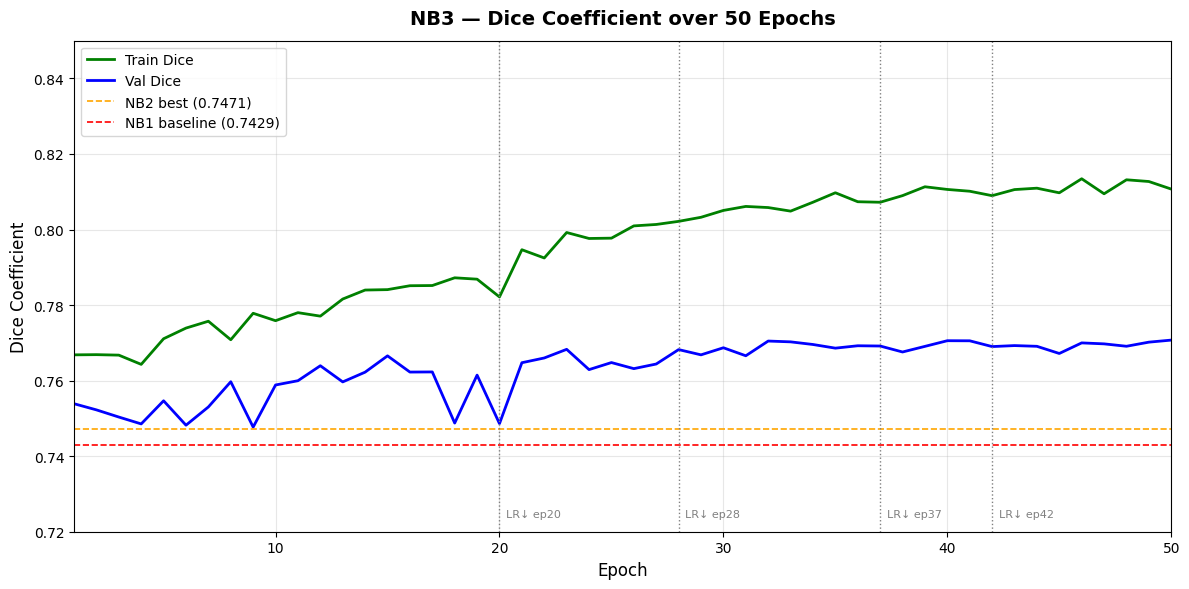

Dice plot saved.


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['dice_coefficient']) + 1)

# ── Plot 1: Dice Coefficient ──
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(epochs, history.history['dice_coefficient'],     'g-',  linewidth=2,   label='Train Dice')
ax1.plot(epochs, history.history['val_dice_coefficient'], 'b-',  linewidth=2,   label='Val Dice')
ax1.axhline(y=0.7471, color='orange', linestyle='--', linewidth=1.2, label='NB2 best (0.7471)')
ax1.axhline(y=0.7429, color='red',    linestyle='--', linewidth=1.2, label='NB1 baseline (0.7429)')

for ep, label in [(20, 'LR↓ ep20'), (28, 'LR↓ ep28'), (37, 'LR↓ ep37'), (42, 'LR↓ ep42')]:
    ax1.axvline(x=ep, color='gray', linestyle=':', linewidth=1)
    ax1.text(ep + 0.3, 0.724, label, fontsize=8, color='gray')

ax1.set_title('NB3 — Dice Coefficient over 50 Epochs', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Dice Coefficient', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim([0.72, 0.85])
ax1.set_xlim([1, 50])
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'NB3_dice_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dice plot saved.")

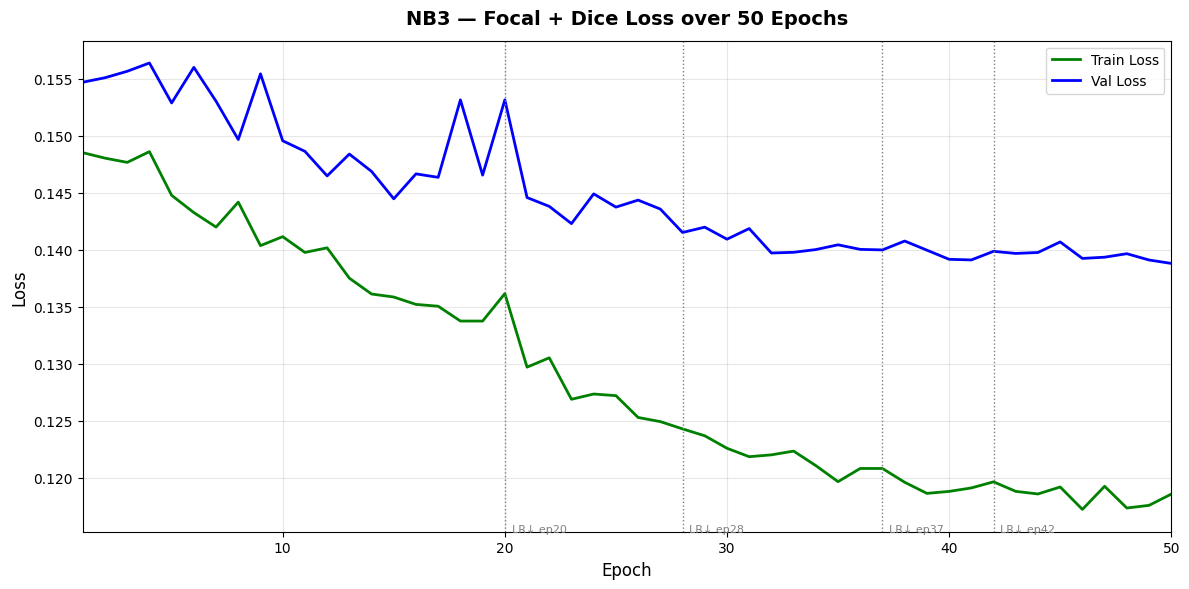

Loss plot saved.


In [ ]:
# ── Plot 2: Loss ──
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(epochs, history.history['loss'],     'g-', linewidth=2, label='Train Loss')
ax2.plot(epochs, history.history['val_loss'], 'b-', linewidth=2, label='Val Loss')

for ep, label in [(20, 'LR↓ ep20'), (28, 'LR↓ ep28'), (37, 'LR↓ ep37'), (42, 'LR↓ ep42')]:
    ax2.axvline(x=ep, color='gray', linestyle=':', linewidth=1)
    ax2.text(ep + 0.3, ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else 0.12, label, fontsize=8, color='gray')

ax2.set_title('NB3 — Focal + Dice Loss over 50 Epochs', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_xlim([1, 50])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'NB3_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss plot saved.")

In [10]:
def compute_metrics(y_true, y_pred_bin):
    results = []
    for i in range(len(y_true)):
        gt   = y_true[i].flatten()
        pred = y_pred_bin[i].flatten()
        TP = np.sum(gt * pred)
        FP = np.sum((1 - gt) * pred)
        FN = np.sum(gt * (1 - pred))
        TN = np.sum((1 - gt) * (1 - pred))
        results.append({
            'dice':        (2*TP + 1e-6) / (2*TP + FP + FN + 1e-6),
            'iou':         (TP  + 1e-6) / (TP  + FP + FN + 1e-6),
            'sensitivity': (TP  + 1e-6) / (TP  + FN + 1e-6),
            'precision':   (TP  + 1e-6) / (TP  + FP + 1e-6),
            'specificity': (TN  + 1e-6) / (TN  + FP + 1e-6)
        })
    return results

print("compute_metrics defined.")

compute_metrics defined.


In [11]:
#Evaluation
# Load best NB3 model
print("Loading best NB3 model...")
model_best = tf.keras.models.load_model(
    BASE + 'NB3_best.keras',
    custom_objects=CUSTOM_OBJECTS,
    compile=False
)
print("Model loaded. Params:", model_best.count_params())

# Run predictions
print("Running predictions on test set...")
y_pred_raw = model_best.predict(X_test, batch_size=2, verbose=1)
y_pred_bin = (y_pred_raw > 0.5).astype(np.float32)

# Compute metrics
results        = compute_metrics(y_test, y_pred_bin)
dice_scores    = [r['dice']        for r in results]
iou_scores     = [r['iou']         for r in results]
sens_scores    = [r['sensitivity'] for r in results]
prec_scores    = [r['precision']   for r in results]
spec_scores    = [r['specificity'] for r in results]

nb1 = {'dice': 0.7234, 'iou': 0.6031, 'sensitivity': 0.7168, 'precision': 0.8229, 'specificity': 0.9994}
nb2 = {'dice': 0.7380, 'iou': 0.6172, 'sensitivity': 0.7957, 'precision': 0.7528, 'specificity': 0.9990}
nb3 = {
    'dice':        np.mean(dice_scores),
    'iou':         np.mean(iou_scores),
    'sensitivity': np.mean(sens_scores),
    'precision':   np.mean(prec_scores),
    'specificity': np.mean(spec_scores),
    'dice_std':    np.std(dice_scores)
}

def arrow(new, old):
    diff = new - old
    sym = '▲' if diff >= 0 else '▼'
    return f"{sym} {abs(diff):.4f}"

print("\n" + "="*72)
print("       NB1 Baseline  vs  NB2 Fine-Tuned  vs  NB3 — Test Set")
print("="*72)
print(f"  {'Metric':<14} {'NB1':>10} {'NB2':>10} {'NB3':>10} {'vs NB1':>12} {'vs NB2':>12}")
print("-"*72)
for metric, name in [('dice','Dice'),('iou','IoU'),('sensitivity','Sensitivity'),('precision','Precision'),('specificity','Specificity')]:
    print(f"  {name:<14} {nb1[metric]:>10.4f} {nb2[metric]:>10.4f} {nb3[metric]:>10.4f} {arrow(nb3[metric], nb1[metric]):>12} {arrow(nb3[metric], nb2[metric]):>12}")
print("-"*72)
print(f"  {'Dice Std':<14} {'0.2219':>10} {'0.2051':>10} {nb3['dice_std']:>10.4f}")
print("="*72)

Loading best NB3 model...
Model loaded. Params: 1478868
Running predictions on test set...
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step

       NB1 Baseline  vs  NB2 Fine-Tuned  vs  NB3 — Test Set
  Metric                NB1        NB2        NB3       vs NB1       vs NB2
------------------------------------------------------------------------
  Dice               0.7234     0.7380     0.7842     ▲ 0.0608     ▲ 0.0462
  IoU                0.6031     0.6172     0.6638     ▲ 0.0607     ▲ 0.0466
  Sensitivity        0.7168     0.7957     0.8136     ▲ 0.0968     ▲ 0.0179
  Precision          0.8229     0.7528     0.7999     ▼ 0.0230     ▲ 0.0471
  Specificity        0.9994     0.9990     0.9993     ▼ 0.0001     ▲ 0.0003
------------------------------------------------------------------------
  Dice Std           0.2219     0.2051     0.1465
